In [1]:
#Amo evaluation
#FM 28.11.2025
import sys
sys.path.append('amos') 
# Import all ML orchestration functions
from amos.ml_orchestration import (
    ml_exp_with_timing,  # Main experiment function with timing preservation
    extract_timing_structure,
    save_midi_with_exact_timing_structure,
    KerasClassifierWrapper,
    build_lstm_classifier,
    build_transformer_classifier,
    clf_predict,
    defineXy,           # Data preparation function
    split_and_encode    # Train/test split with encoding
)
# Import MIDI processing functions  
from amos.midi2df2midi import midi_to_dataframe, save_midi_from_df
from amos.mappings import fill_quaterna_columns, learn_quaterna_mapping
# Import amo funtion
from amos.ml_orchestration import amo_with_doublings_multiclass

import pandas as pd
import numpy as np
from collections import defaultdict


from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt



/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
2025-12-10 18:46:28.024095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765388788.040033   98160 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been

In [2]:
def transpose(note, inverse=False, n_semitones=12):
    # Example: transpose pitch
    if inverse:
        n_semitones = - n_semitones
    new_note = note.copy()
    new_note['pitch'] = note['pitch'] + n_semitones
    return [ new_note ]

In [3]:
transformations = [
    (transpose, {'n_semitones': 12}),
    (transpose, {'n_semitones': 24}),
    (transpose, {'n_semitones': 46}),
    (transpose, {'n_semitones': -12}),
    (transpose, {'n_semitones': -24}),
    (transpose, {'n_semitones': -46}),
    #(split_duration, {'smallest_unit': 0.25}),
]

In [4]:
"""
Prompt by GV
create a python function to read the path of .mid files which contain the string "orch". Files are inside folders like "folder_name1/la_mer_1_orch.mid", "folder_name2/symphony_9_2_orch.mid", etc.
"""
import os

def find_orch_mid_files(root_dir='.'):
    result = []
    for dirpath, _, filenames in os.walk(root_dir):
        for name in filenames:
            if name.lower().endswith('.mid') and 'orch' in name.lower():
                result.append(os.path.join(dirpath, name))
    return result

In [5]:
root_dir='LOP_database_06_09_17/hand_picked_Spotify'
filenames = find_orch_mid_files(root_dir)
len(filenames)

55

In [6]:
model_names = [
        "XGBoost",
        "XGBoost5",
        "XGBoost10",
        "XGBoost20",
        "XGBoost50",
        "RandomForest",
        "DecisionTree",
        #"LSTMClassifier",      # Added
        "NearestNeighbors",
        #"MLP3",   
        #"TransformerClassifier", # Added
        "NaiveBayes",
        #"MLP1",
        "AdaBoost",
        "Dummy0",
        "Dummy1",
        "DummyUnif",      
    ]

model_names_short = [
    'XGB',
    'XGB5',
    'XGB10',
    'XGB20',
    'XGB50',
    'RF',
    'DT',
    #'LSTM*',
    'NN',
    #'MLP3*',
    #'TF',
    'NB',
    #'MLP1',
    'AB',
    'D0',
    'D1',
    'DU',
    ]

classifiers = [
    XGBClassifier(),
    XGBClassifier(n_estimators = 5),
    XGBClassifier(n_estimators = 10),
    XGBClassifier(n_estimators = 20),
    XGBClassifier(n_estimators = 50),
    RandomForestClassifier(),
    DecisionTreeClassifier(),
    #KerasClassifierWrapper(build_lstm_classifier),      # Added LSTM
    KNeighborsClassifier(1),
    #MLPClassifier(hidden_layer_sizes=(128,128,128)),
    #KerasClassifierWrapper(build_transformer_classifier),# Added Transformer
    GaussianNB(),
    #MLPClassifier(),
    AdaBoostClassifier(),
    DummyClassifier(strategy='constant', constant=0),
    DummyClassifier(strategy='constant', constant=1),
    DummyClassifier(strategy='uniform'),
]

In [7]:
# Reduce for testing purposes, remove this cell for the actual experiment
N_files = len(filenames)
N_models = len(classifiers)

filenames = filenames[:N_files]

model_names = model_names[:N_models]
classifiers = classifiers[:N_models]
model_names_short = model_names_short[:N_models]

In [8]:
# Initialize metrics collectors
s = len(model_names)
ml_metrics = dict()
base_metrics_names = ["time",
                      "accuracy (train)",
                      "accuracy (test)",
                      "precision (train)",
                      "precision (test)",
                      "recall (train)",
                      "recall (test)",
                      "f1 (train)",
                      "f1 (test)",
                      ] #, "n_events", "n_classes"]
ml_metrics_names = base_metrics_names.copy()

for func, kwargs in transformations:
    trans_target_name = f"{func.__name__}_{kwargs}"
    for bmn in base_metrics_names:
        ml_metrics_names.append(f"{bmn} ({trans_target_name})")

for mn in ml_metrics_names:
    ml_metrics[mn] = np.zeros(s)

In [9]:
# Multiclass, with transformations
error_collection = []
filein = filenames
for u, (model_name, clf) in enumerate(zip(model_names, classifiers)):
    try: 
        # TODO: Uniform instruments throughout pieces, try with a ytarget that takes names from csv in LOP
        metrics = amo_with_doublings_multiclass(filein, fileout=None, ytarget="instrument-name", model=model_name, tol=0.2, transformations=transformations, pipeline_path=f"weights/train_all_{model_name}")
        print(metrics)
        for mn in ml_metrics_names:
            # ml_metrics["accuracy"][u] = metrics["accuracy"]
            ml_metrics[mn][u] = metrics[mn]
    except Exception as e:
        print("Error")
        error_collection.append(f"Error with model {model_name}: {e}")

print("\n????????? ERRORS ??????????")
for error in error_collection:
    print(error)

Learning orchestration style from 55 files

========= PREPROCESSING =========
[PREPROCESSING] Computing and caching results...

Building reduced dataset with transformations. LOP_database_06_09_17/hand_picked_Spotify/58/swan_lake_26_orch.mid
{'transformed': 308, 'direct': 39, 'none': 3973}
Original size: (4320, 15)
Dropping [901, 902, 903, 905, 906, 907, 909, 911, 913, 915, 916, 917, 919, 921, 923, 925, 927, 929, 930, 932, 936, 945, 946, 949, 479, 960, 711, 713, 715, 487, 968, 496, 498, 500, 502, 504, 506, 508, 510, 512, 514, 516, 518, 520, 522, 524, 526, 1375, 1376, 1379, 1193, 1381, 1384, 1385, 2762, 2763, 527, 528, 1284, 1285, 3108, 3109, 992, 741, 2765, 529, 1286, 1287, 3110, 3111, 994, 995, 1200, 2767, 1288, 1289, 3112, 3113, 996, 997, 1202, 2768, 533, 1290, 1291, 3114, 998, 999, 2770, 535, 536, 1292, 1293, 3116, 1000, 1001, 2771, 2772, 537, 1294, 1295, 3118, 1002, 1003, 1339, 2773, 540, 1296, 1297, 3120, 3121, 1005, 753, 2774, 541, 542, 1298, 1299, 3122, 3123, 1006, 1007, 1212, 7

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Labels [0 1 2 3 4 5 6 8]
Number of events: 441582
Last onset at 2078.75
y_train, test size: 0.2 , labels: [0 1 2 3 4 5 6 8]
Number of unknown classes in test set: 0 of 0.2
y_train, test size: 0 , labels: [0 1 2 3 4 5 6 8]
--------- XGBoost ---------
Train Time (sec): 10.1706
Score on Test Set (20% split): 0.8951
Precision (weighted): 0.8814
Recall (weighted): 0.8951
F1-Score (weighted): 0.8779
Confusion Matrix:
 [[74337   823    88    24     1     3     0]
 [ 6216  3660   147     9     5     1     1]
 [  998   459   879    39     3     3     0]
 [  211    53    86   159     6     3     0]
 [   37     5    20     8    14     0     0]
 [    6     0     3     3     0     2     0]
 [    0     0     1     2     0     1     1]]
Pipeline saved: transpose_{'n_semitones': 12}.joblib
transpose_{'n_semitones': 24}
0    0.964278
1    0.027105
2    0.006352
3    0.001741
4    0.000401
5    0.000095
6    0.000016
8    0.000007
9    0.000002
7    0.000002
Name: proportion, dtype: float64
Labels [0 1 

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Labels [0 1 2 3 4 5 6 8]
Number of events: 441582
Last onset at 2078.75
y_train, test size: 0.2 , labels: [0 1 2 3 4 5 6 8]
Number of unknown classes in test set: 0 of 0.2
y_train, test size: 0 , labels: [0 1 2 3 4 5 6 8]
--------- XGBoost ---------
Train Time (sec): 9.8162
Score on Test Set (20% split): 0.8951
Precision (weighted): 0.8814
Recall (weighted): 0.8951
F1-Score (weighted): 0.8779
Confusion Matrix:
 [[74337   823    88    24     1     3     0]
 [ 6216  3660   147     9     5     1     1]
 [  998   459   879    39     3     3     0]
 [  211    53    86   159     6     3     0]
 [   37     5    20     8    14     0     0]
 [    6     0     3     3     0     2     0]
 [    0     0     1     2     0     1     1]]
Pipeline saved: transpose_{'n_semitones': 12}.joblib
transpose_{'n_semitones': 24}
0    0.964278
1    0.027105
2    0.006352
3    0.001741
4    0.000401
5    0.000095
6    0.000016
8    0.000007
9    0.000002
7    0.000002
Name: proportion, dtype: float64
Labels [0 1 2

...

Labels [0 1 2 3 4 5 6 8]
Number of events: 441582
Last onset at 2078.75
y_train, test size: 0.2 , labels: [0 1 2 3 4 5 6 8]
Number of unknown classes in test set: 0 of 0.2
y_train, test size: 0 , labels: [0 1 2 3 4 5 6 8]
--------- XGBoost ---------
Train Time (sec): 39.3755
Score on Test Set (20% split): 0.8951
Precision (weighted): 0.8814
Recall (weighted): 0.8951
F1-Score (weighted): 0.8779
Confusion Matrix:
 [[74337   823    88    24     1     3     0]
 [ 6216  3660   147     9     5     1     1]
 [  998   459   879    39     3     3     0]
 [  211    53    86   159     6     3     0]
 [   37     5    20     8    14     0     0]
 [    6     0     3     3     0     2     0]
 [    0     0     1     2     0     1     1]]
Pipeline saved: transpose_{'n_semitones': 12}.joblib
transpose_{'n_semitones': 24}
0    0.964278
1    0.027105
2    0.006352
3    0.001741
4    0.000401
5    0.000095
6    0.000016
8    0.000007
9    0.000002
7    0.000002
Name: proportion, dtype: float64
Labels [0 1 

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Labels [0 1 2 3 4 5 6 8]
Number of events: 441582
Last onset at 2078.75
y_train, test size: 0.2 , labels: [0 1 2 3 4 5 6 8]
Number of unknown classes in test set: 0 of 0.2
y_train, test size: 0 , labels: [0 1 2 3 4 5 6 8]
--------- XGBoost ---------
Train Time (sec): 37.4268
Score on Test Set (20% split): 0.8951
Precision (weighted): 0.8814
Recall (weighted): 0.8951
F1-Score (weighted): 0.8779
Confusion Matrix:
 [[74337   823    88    24     1     3     0]
 [ 6216  3660   147     9     5     1     1]
 [  998   459   879    39     3     3     0]
 [  211    53    86   159     6     3     0]
 [   37     5    20     8    14     0     0]
 [    6     0     3     3     0     2     0]
 [    0     0     1     2     0     1     1]]
Pipeline saved: transpose_{'n_semitones': 12}.joblib
transpose_{'n_semitones': 24}
0    0.964278
1    0.027105
2    0.006352
3    0.001741
4    0.000401
5    0.000095
6    0.000016
8    0.000007
9    0.000002
7    0.000002
Name: proportion, dtype: float64
Labels [0 1 

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Labels [0 1 2 3 4 5 6 8]
Number of events: 441582
Last onset at 2078.75
y_train, test size: 0.2 , labels: [0 1 2 3 4 5 6 8]
Number of unknown classes in test set: 0 of 0.2
y_train, test size: 0 , labels: [0 1 2 3 4 5 6 8]
--------- XGBoost ---------
Train Time (sec): 12.5050
Score on Test Set (20% split): 0.8951
Precision (weighted): 0.8814
Recall (weighted): 0.8951
F1-Score (weighted): 0.8779
Confusion Matrix:
 [[74337   823    88    24     1     3     0]
 [ 6216  3660   147     9     5     1     1]
 [  998   459   879    39     3     3     0]
 [  211    53    86   159     6     3     0]
 [   37     5    20     8    14     0     0]
 [    6     0     3     3     0     2     0]
 [    0     0     1     2     0     1     1]]
Pipeline saved: transpose_{'n_semitones': 12}.joblib
transpose_{'n_semitones': 24}
0    0.964278
1    0.027105
2    0.006352
3    0.001741
4    0.000401
5    0.000095
6    0.000016
8    0.000007
9    0.000002
7    0.000002
Name: proportion, dtype: float64
Labels [0 1 

In [10]:
def return_m_std(ml_metrics, metric_name):
    print(metric_name)
    mean = np.nanmean(ml_metrics, axis=0)
    std = np.nanstd(ml_metrics, axis=0)
    print(mean)
    print(std)
    return mean, std

In [11]:
print(ml_metrics)

{'time': array([  64.98535442,   25.18098593,   24.3079896 ,   30.10107899,
         78.55314851, 1301.87722492,   41.90022707, 1504.63128471,
         21.00884628, 1295.52299285,    1.84730077,    2.93980098,
          2.68413448]), 'accuracy (train)': array([0.58157664, 0.3486917 , 0.40448613, 0.44639796, 0.5240556 ,
       0.99952663, 1.        , 1.        , 0.10520742, 0.23578588,
       0.        , 0.        , 0.        ]), 'accuracy (test)': array([0.56440258, 0.35075496, 0.40701316, 0.44659416, 0.51685925,
       0.65371171, 0.59199155, 0.54250619, 0.10693305, 0.23712191,
       0.        , 0.        , 0.        ]), 'precision (train)': array([0.85044187, 0.79409515, 0.80107092, 0.80195824, 0.82725072,
       0.99998852, 1.        , 1.        , 0.44956807, 0.80466008,
       0.        , 0.02811851, 0.02816913]), 'precision (test)': array([0.82890713, 0.79597473, 0.79819552, 0.79746517, 0.81626295,
       0.78135487, 0.70566324, 0.61534472, 0.45662705, 0.80496255,
       0.      

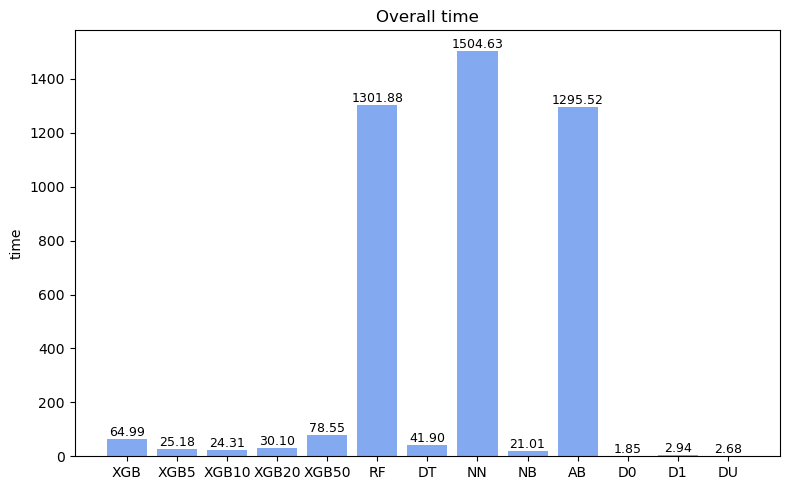

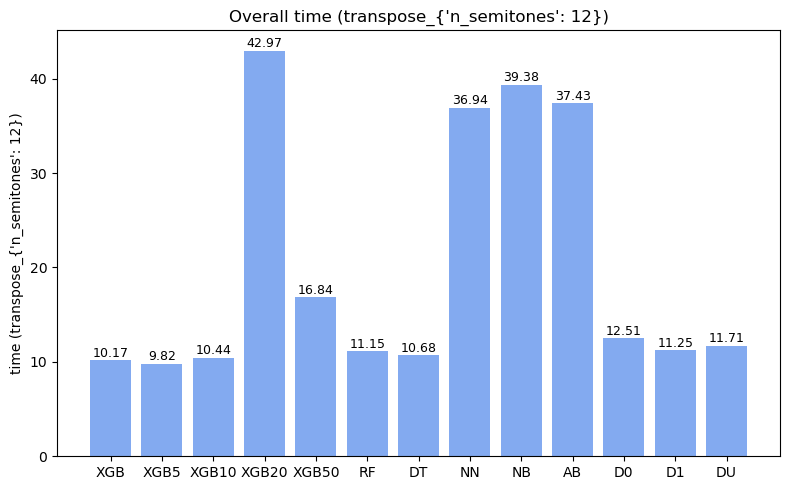

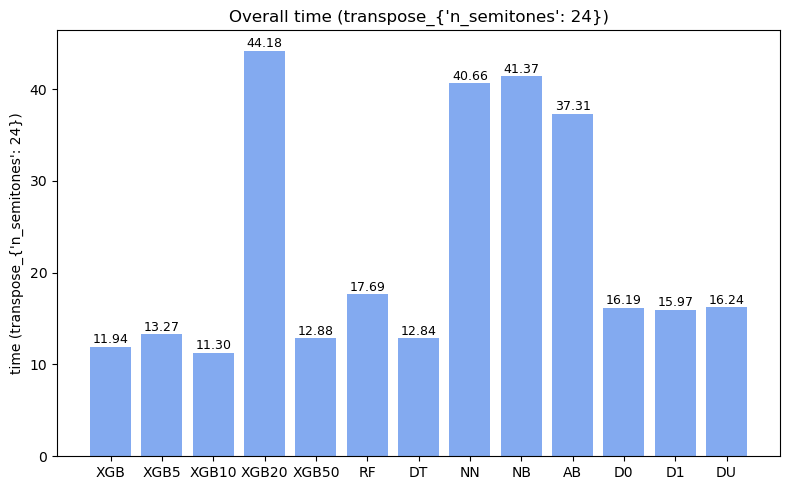

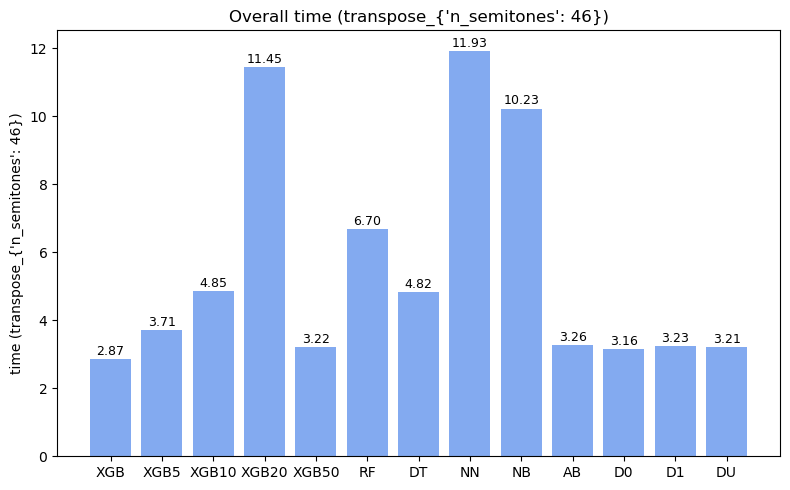

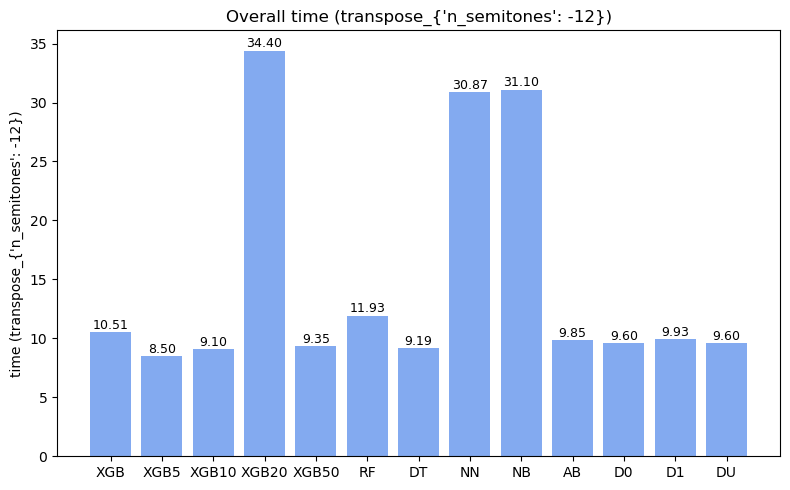

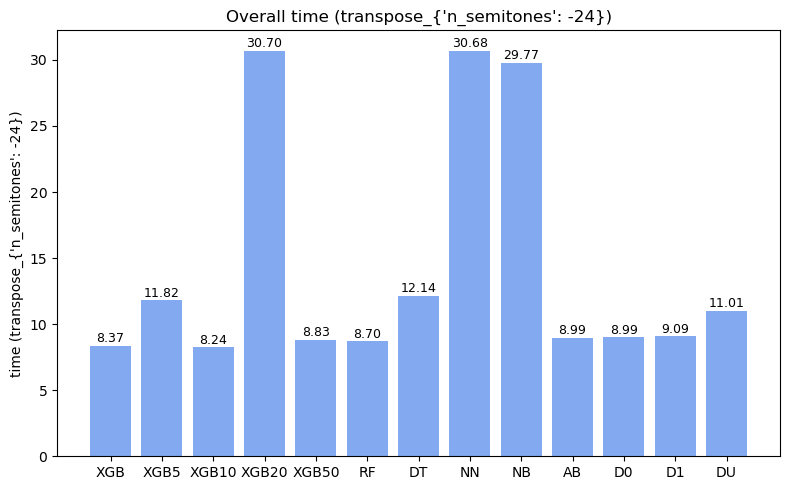

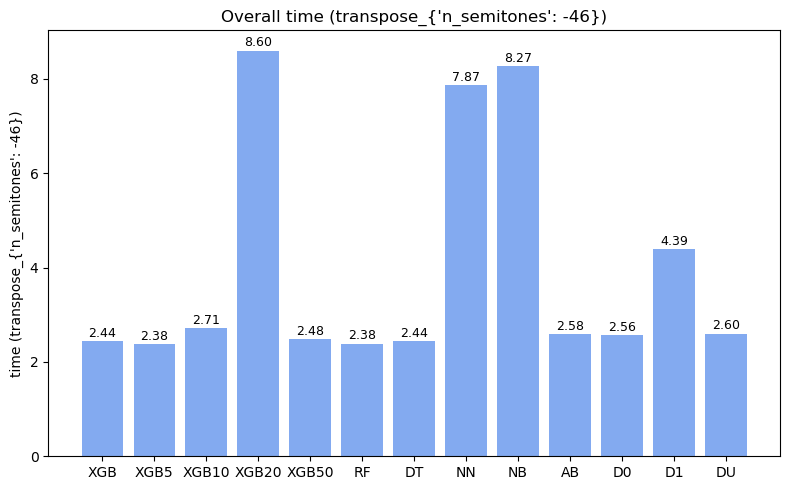

In [12]:
for mn in ml_metrics_names:
    if "time" in mn:
        # Plot
        plt.figure(figsize=(8, 5))
        barlist = plt.bar(model_names_short, ml_metrics[mn], capsize=5, color='cornflowerblue', alpha=0.8)

        plt.ylabel(mn)
        plt.title(f'Overall {mn}')
        if not "time" in mn:
            plt.ylim(0, 1.1)

        # Optional: Add values above bars
        for i, val in enumerate(ml_metrics[mn]):
            plt.text(i, val + 0.03, f"{val:.2f}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

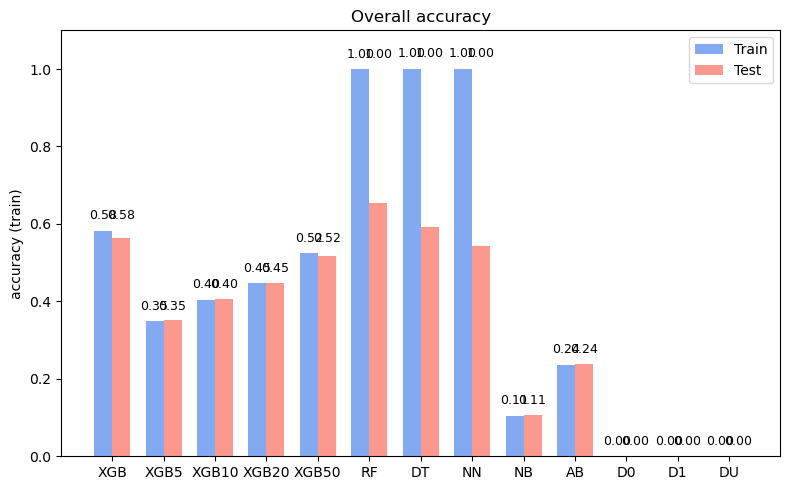

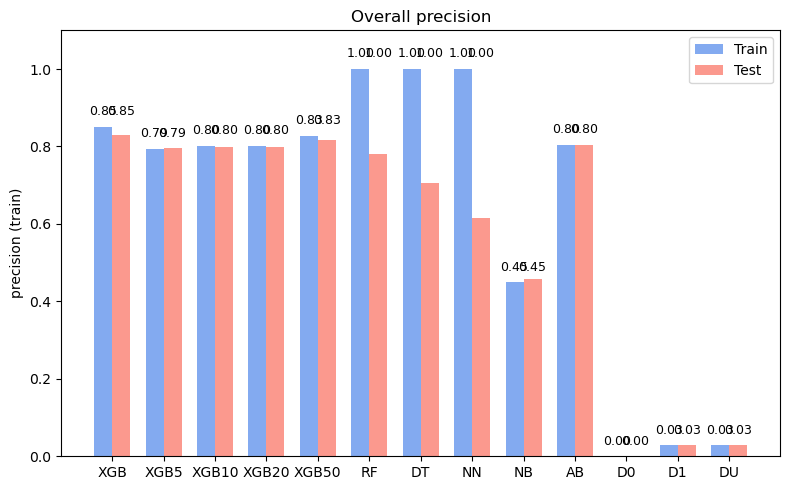

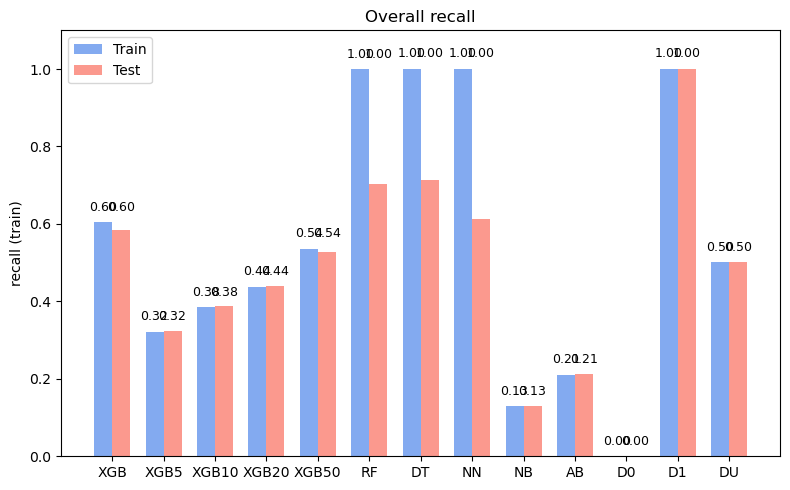

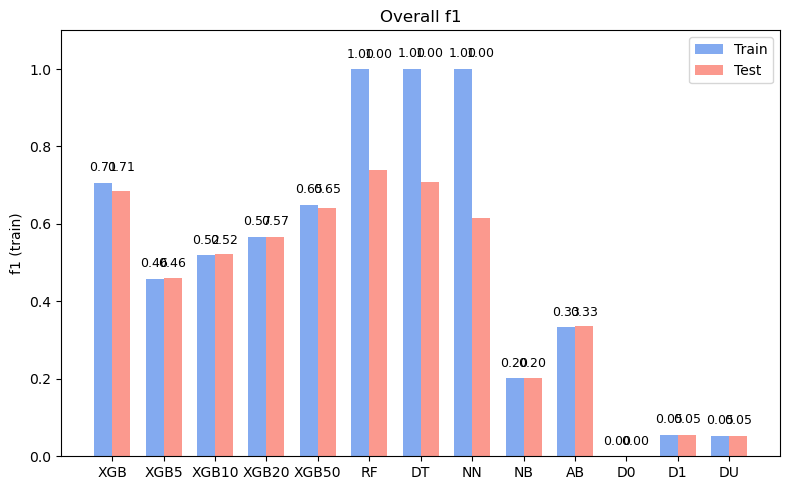

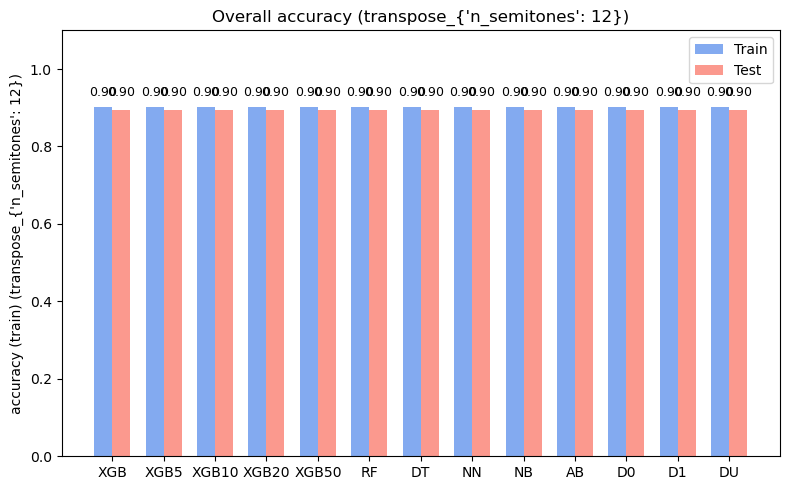

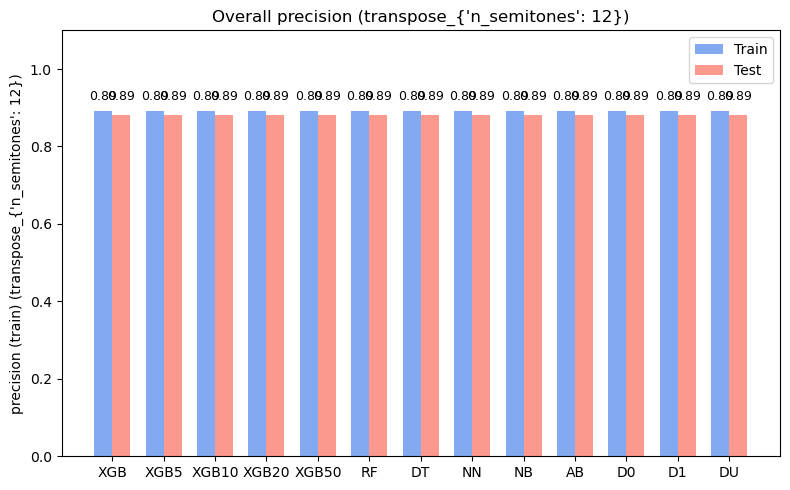

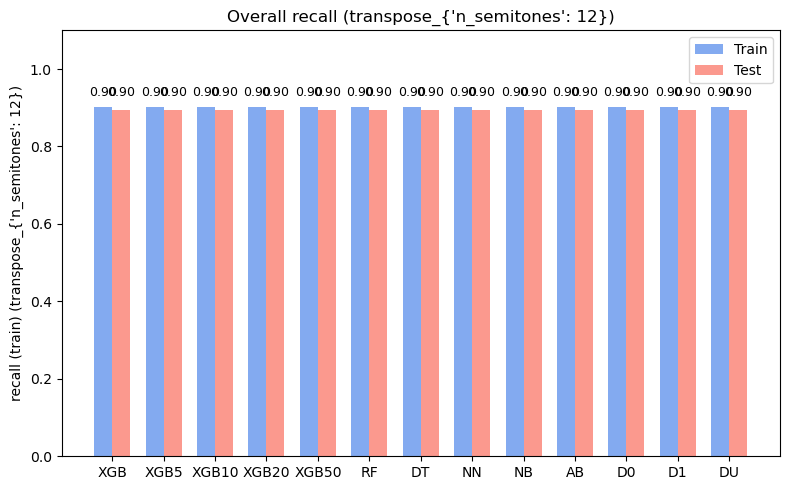

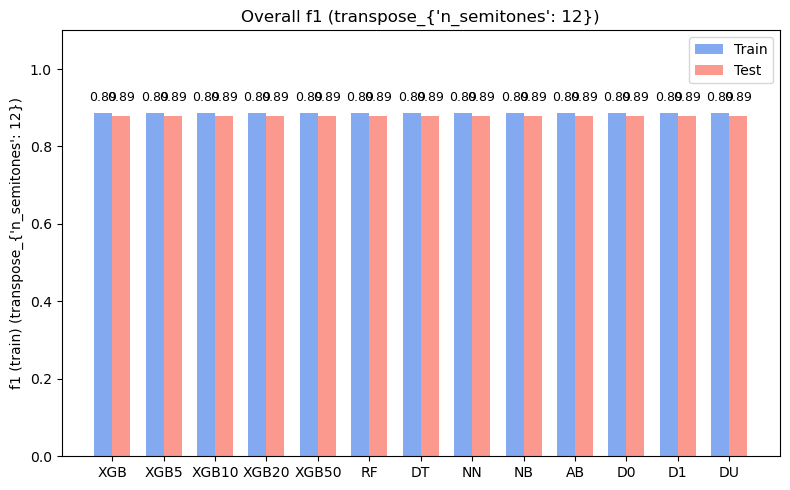

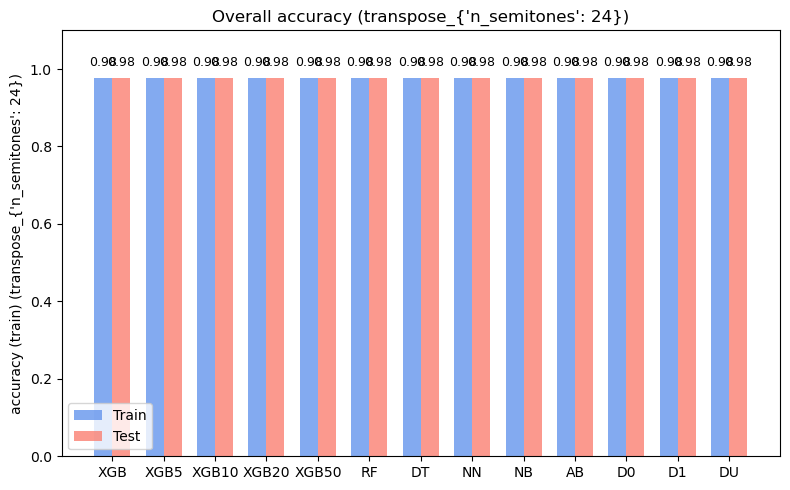

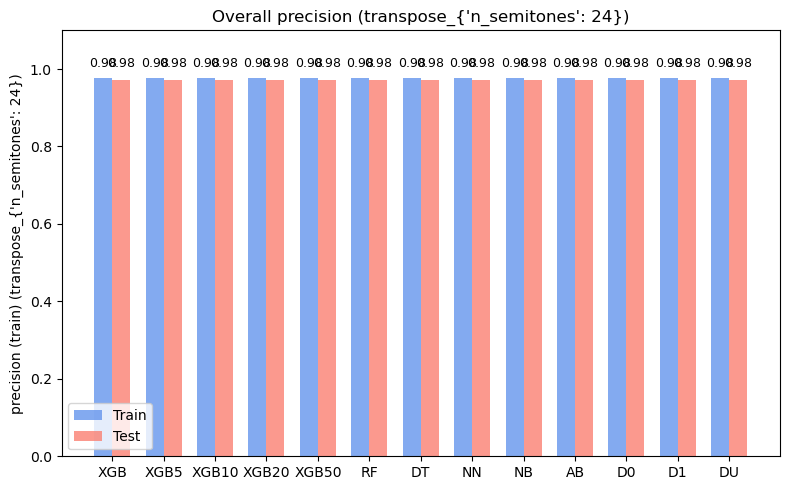

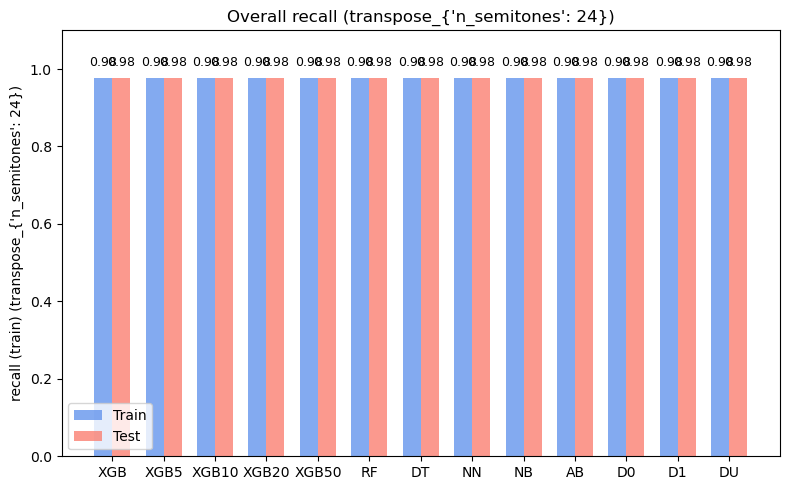

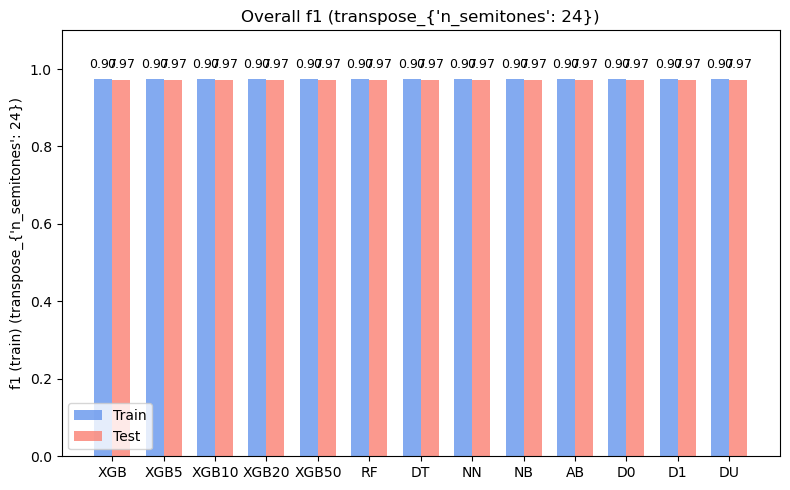

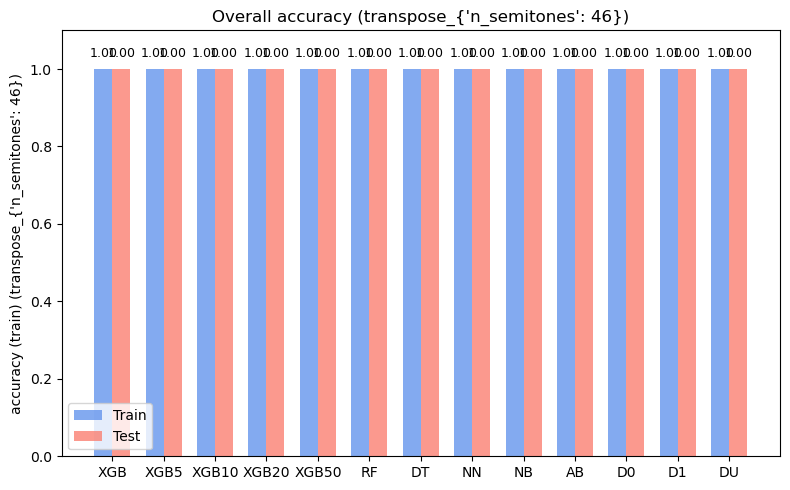

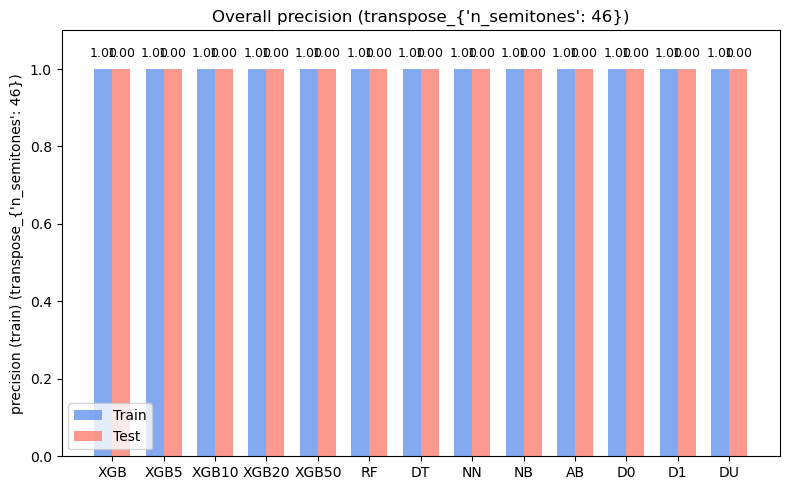

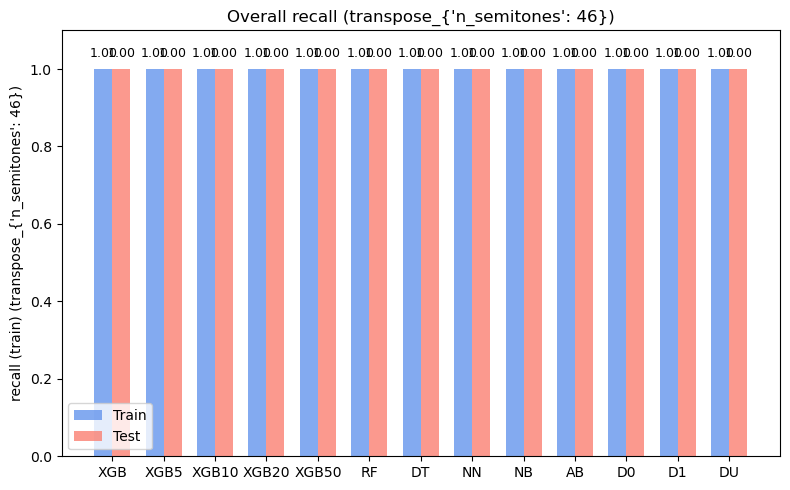

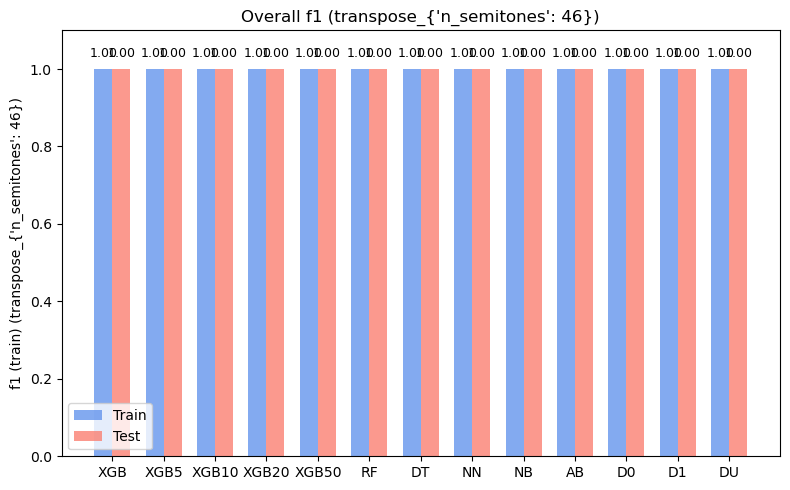

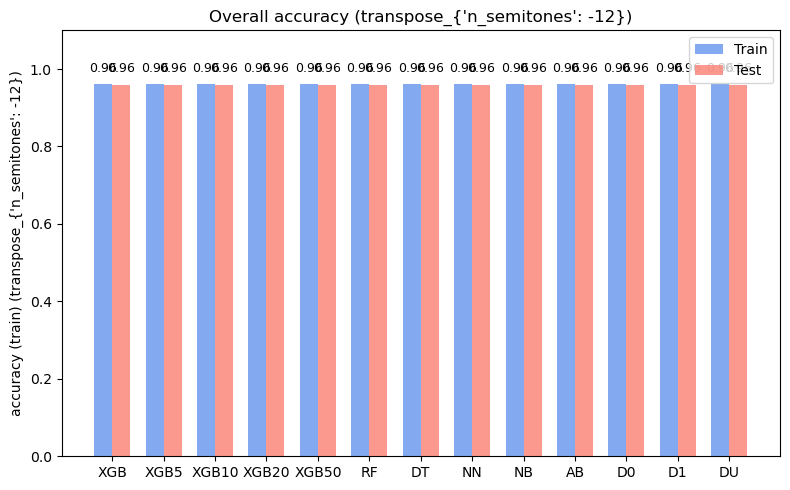

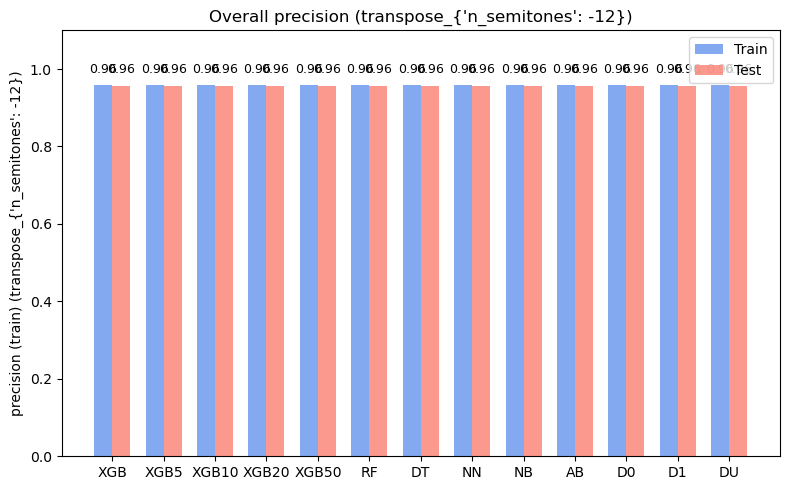

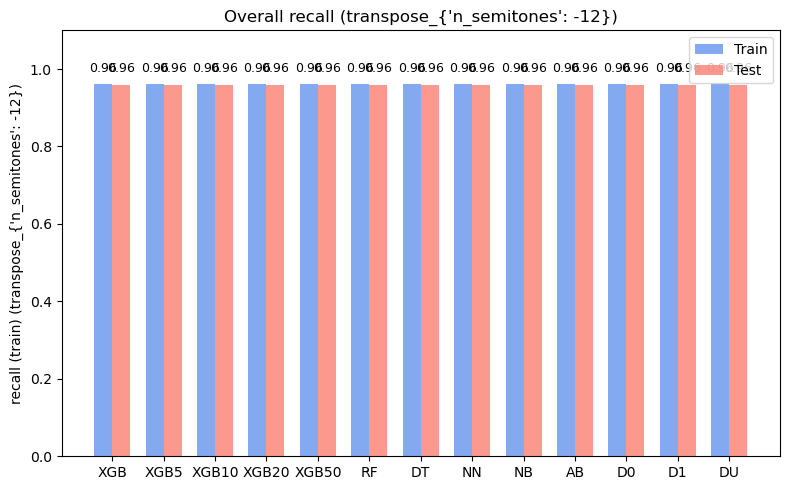

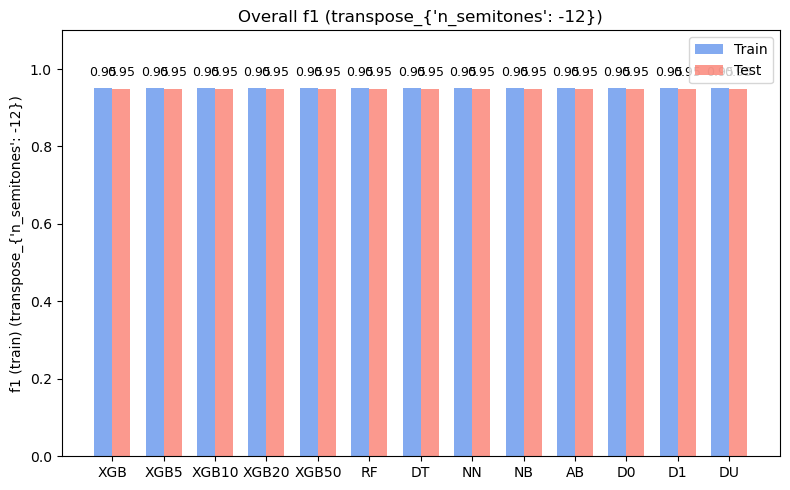

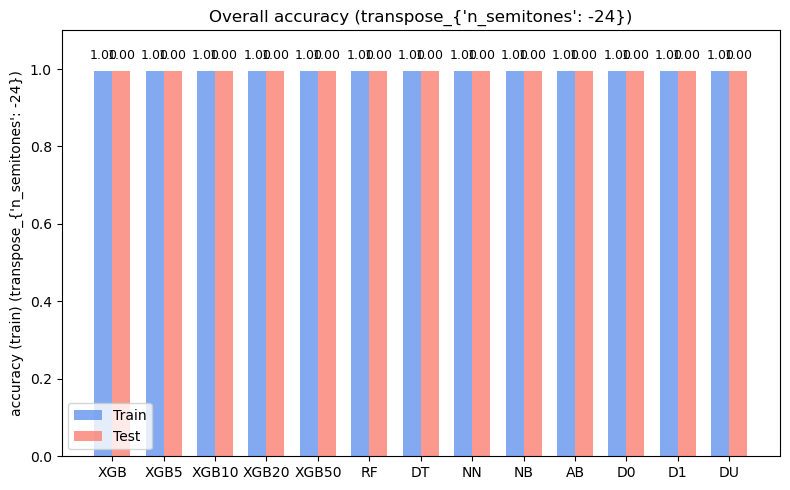

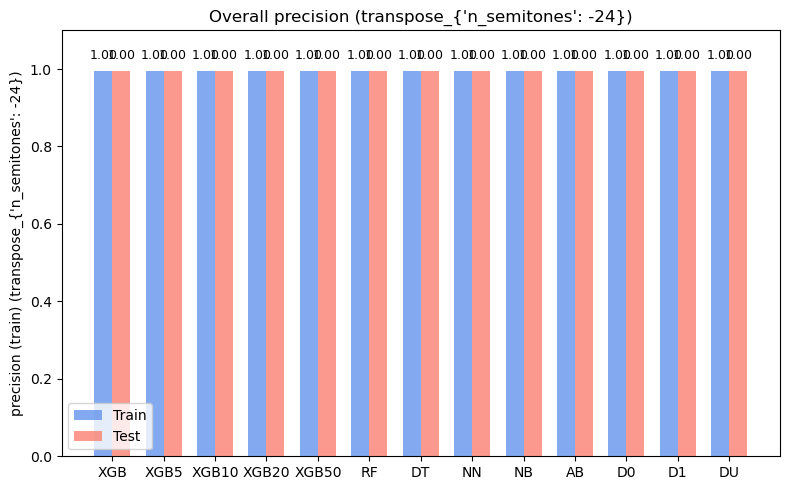

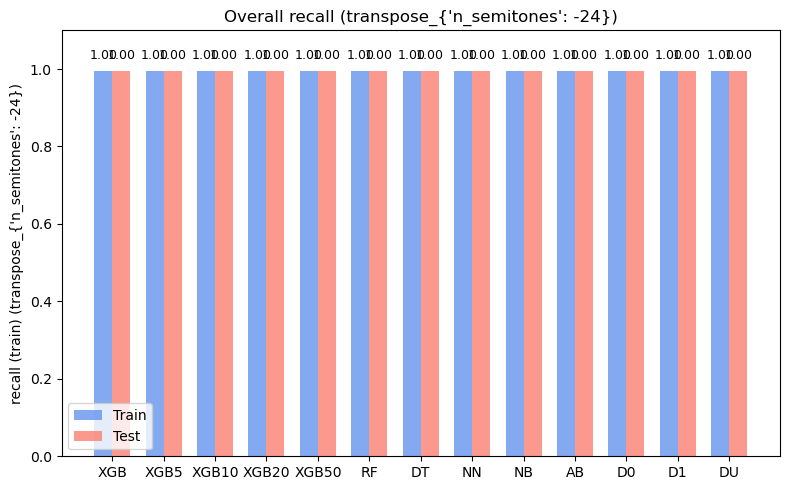

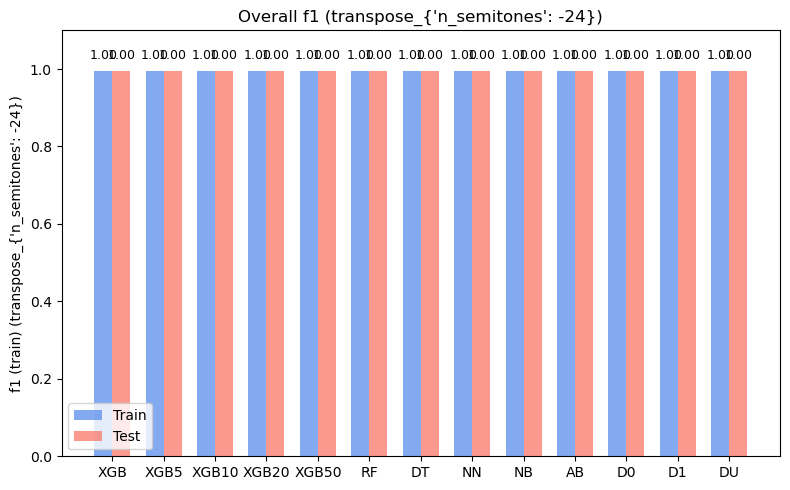

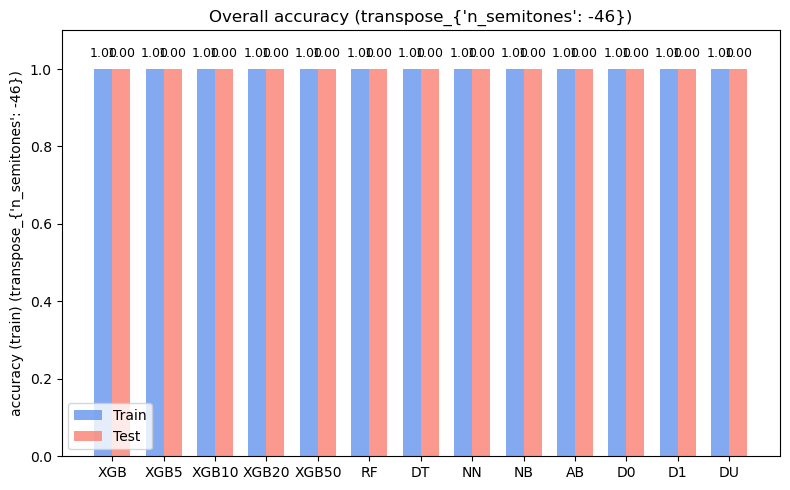

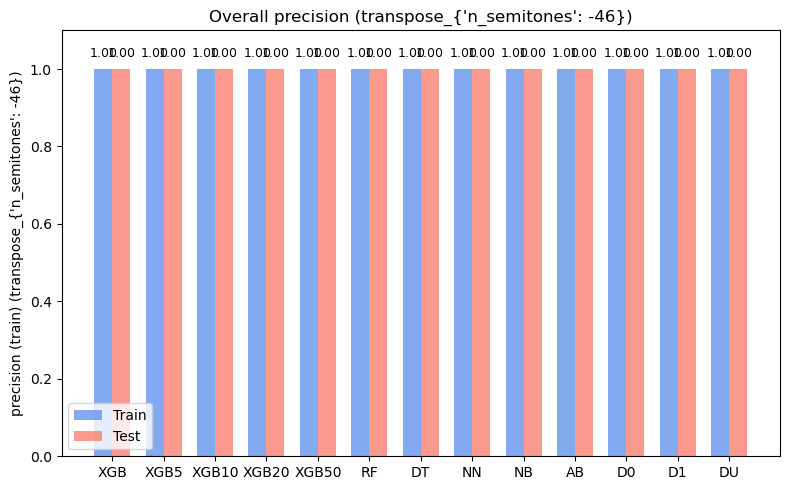

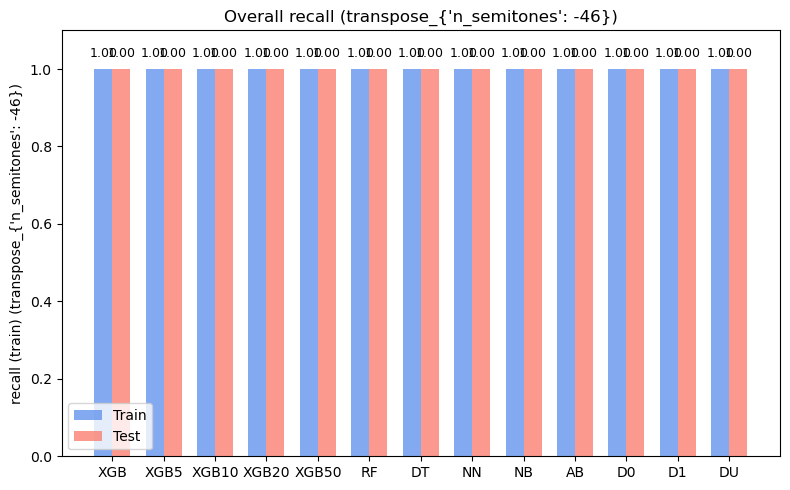

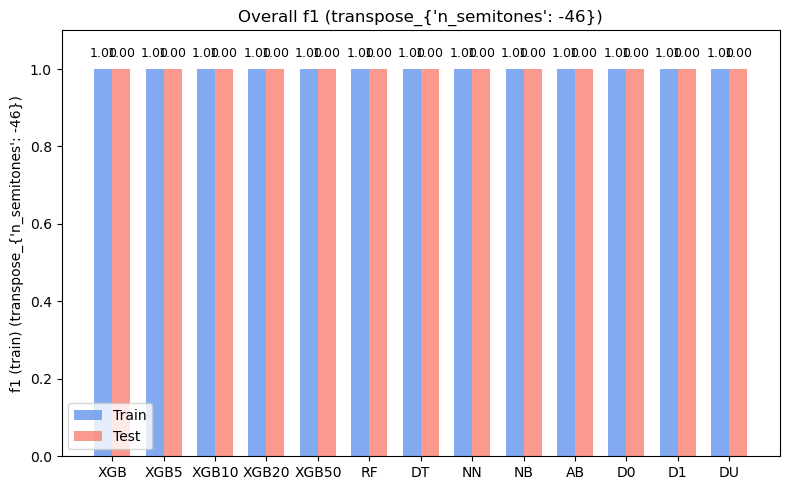

In [13]:
for mn in ml_metrics_names:
    if "train" in mn:
        mn_train = mn
        mn_test = mn.replace("train", "test")

        # Data for the two series
        train_metrics = ml_metrics[mn_train]
        test_metrics  = ml_metrics[mn_test]

        x = np.arange(len(model_names_short))   # positions
        width = 0.35

        plt.figure(figsize=(8, 5))

        # Two bar groups
        plt.bar(x - width/2, train_metrics, width,
                capsize=5,
                label='Train', color='cornflowerblue', alpha=0.8)

        plt.bar(x + width/2, test_metrics, width,
                capsize=5,
                label='Test', color='salmon', alpha=0.8)

        # Labels & layout
        plt.xticks(x, model_names_short)
        plt.ylabel(mn)
        plt.title(f'Overall {mn.replace(" (train)", "")}')

        if "time" not in mn:
            plt.ylim(0, 1.1)

        # Add mean value labels above bars
        for i, val in enumerate(train_metrics):
            plt.text(x[i] - width/2, val + 0.03, f"{val:.2f}",
                    ha='center', fontsize=9)

        for i, val in enumerate(train_metrics):
            plt.text(x[i] + width/2, val + 0.03, f"{val:.2f}",
                    ha='center', fontsize=9)

        plt.legend()
        plt.tight_layout()
        plt.show()

In [14]:
# Renitialize metrics collectors
s = len(model_names)
ml_metrics = dict()
base_metrics_names = ["time",
                      "accuracy (train)",
                      "accuracy (test)",
                      "precision (train)",
                      "precision (test)",
                      "recall (train)",
                      "recall (test)",
                      "f1 (train)",
                      "f1 (test)",
                      ] #, "n_events", "n_classes"]
ml_metrics_names = base_metrics_names.copy()

for mn in ml_metrics_names:
    ml_metrics[mn] = np.zeros(s)

In [15]:
# Single-class, without transformations
error_collection = []
filein = filenames   
for u, (model_name, clf) in enumerate(zip(model_names, classifiers)):
    try: 
        metrics = amo_with_doublings_multiclass(filein,fileout=None, ytarget="instrument-name", model=model_name, tol=0.2, transformations=None, multiclass=False)
        print(metrics)
        for mn in ml_metrics_names:
            # ml_metrics["accuracy"][u] = metrics["accuracy"]
            ml_metrics[mn][u] = metrics[mn]
    except Exception as e:
        print("Error")
        error_collection.append(f"Error with model {model_name}: {e}")

print("\n????????? ERRORS ??????????")
for error in error_collection:
    print(error)

Learning orchestration style from 55 files

========= PREPROCESSING =========
[PREPROCESSING] Computing and caching results...
Mapping: [[1 '2 Cornets à piston in A' 1 56]
 [2 '2 Cornets à piston in Bb' 1 56]
 [3 'Bass drum' 1 0]
 [4 'Bass-Trombone and Bass-Tuba' 1 58]
 [5 'Bassoon' 1 70]
 [6 'Castanets' 1 0]
 [7 'Celesta' 1 8]
 [8 'Clarinet' 1 71]
 [9 'Contrabass' 1 45]
 [10 'Contrabass and Violoncello' 1 48]
 [11 'Contrabass-Clarinet-Bb' 1 71]
 [12 'Contrabassoon' 1 70]
 [13 'Cornet' 1 56]
 [14 'Cymbal' 1 0]
 [15 'Drum' 1 0]
 [16 'English-Horn' 1 0]
 [17 'English-Horn and Oboe' 1 68]
 [18 'Flute' 1 73]
 [19 'Flute and Piccolo' 1 73]
 [20 'Glockenspiel' 1 9]
 [21 'Harp' 1 46]
 [22 'Harpsichord and Violin and Violoncello' 1 48]
 [23 'Horn' 1 60]
 [24 'Oboe' 1 68]
 [25 'Ophicleïde' 1 58]
 [26 'Organ' 1 79]
 [27 'Percussion' 1 0]
 [28 'Piano' 1 0]
 [29 'Piccolo' 1 73]
 [30 'Tam tam' 1 0]
 [31 'Timpani' 1 47]
 [32 'Track 15' 1 48]
 [33 'Track 8' 1 0]
 [34 'Triangle' 1 0]
 [35 'Trombone' 1

In [16]:
print(ml_metrics)

{'time': array([1.89866391e+02, 1.53392696e+01, 2.61019447e+01, 5.31216035e+01,
       1.25426327e+02, 1.71908355e+02, 3.73309588e+00, 5.01228588e+01,
       3.00217915e+00, 5.68026290e+01, 1.11268282e-01, 1.12587452e-01,
       1.15931273e-01]), 'accuracy (train)': array([0.70853735, 0.56346129, 0.58252375, 0.60752949, 0.65966857,
       0.94604896, 0.94608492, 0.9455775 , 0.33703515, 0.17441291,
       0.00632685, 0.00609112, 0.02102224]), 'accuracy (test)': array([0.68904924, 0.56101868, 0.5794857 , 0.60306692, 0.64994167,
       0.7176967 , 0.70263381, 0.59094469, 0.33632194, 0.17543271,
       0.00636877, 0.00600917, 0.02082434]), 'precision (train)': array([0.70853735, 0.56346129, 0.58252375, 0.60752949, 0.65966857,
       0.94604896, 0.94608492, 0.9455775 , 0.33703515, 0.17441291,
       0.00632685, 0.00609112, 0.02136186]), 'precision (test)': array([6.88589153e-01, 5.62410174e-01, 5.81679261e-01, 6.03713535e-01,
       6.49541992e-01, 7.16728304e-01, 7.04805710e-01, 5.90430638

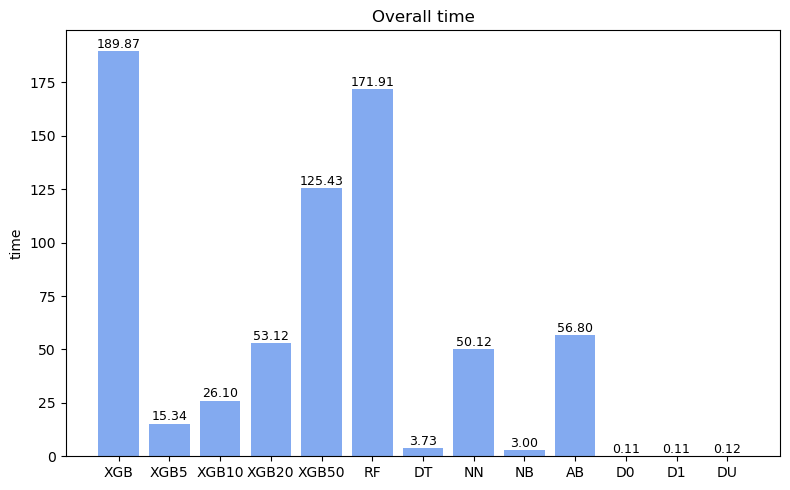

In [17]:
for mn in ml_metrics_names:
    if "time" in mn:
        # Plot
        plt.figure(figsize=(8, 5))
        barlist = plt.bar(model_names_short, ml_metrics[mn], capsize=5, color='cornflowerblue', alpha=0.8)

        plt.ylabel(mn)
        plt.title(f'Overall {mn}')
        if not "time" in mn:
            plt.ylim(0, 1.1)

        # Optional: Add values above bars
        for i, val in enumerate(ml_metrics[mn]):
            plt.text(i, val + 0.03, f"{val:.2f}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

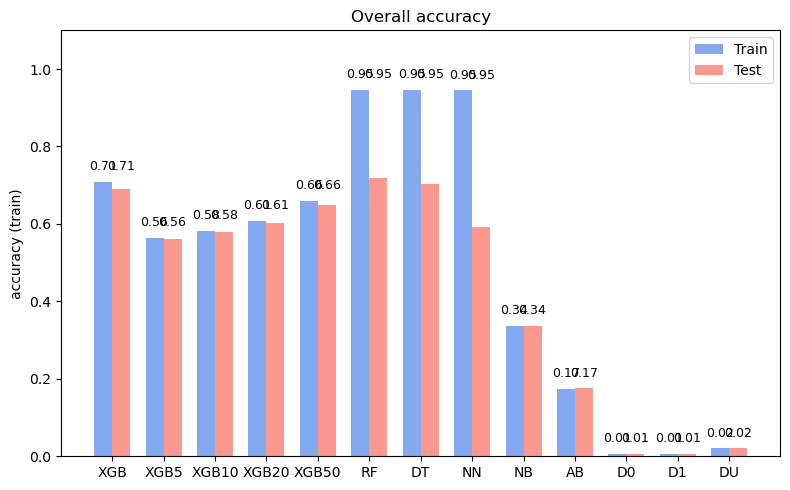

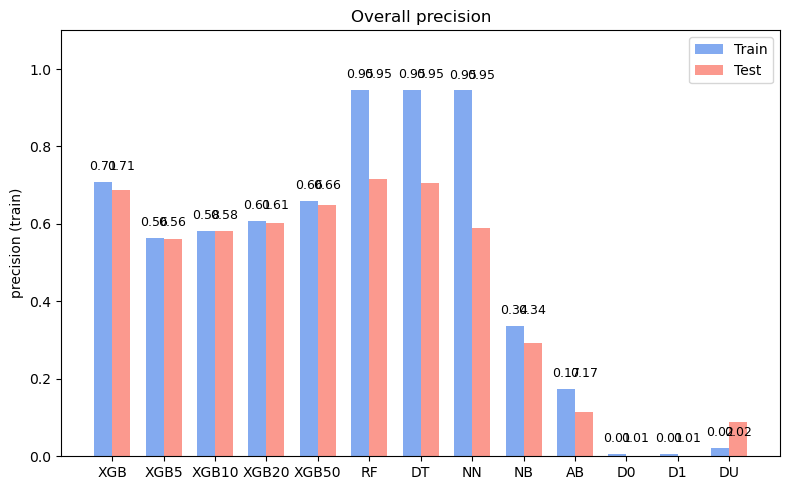

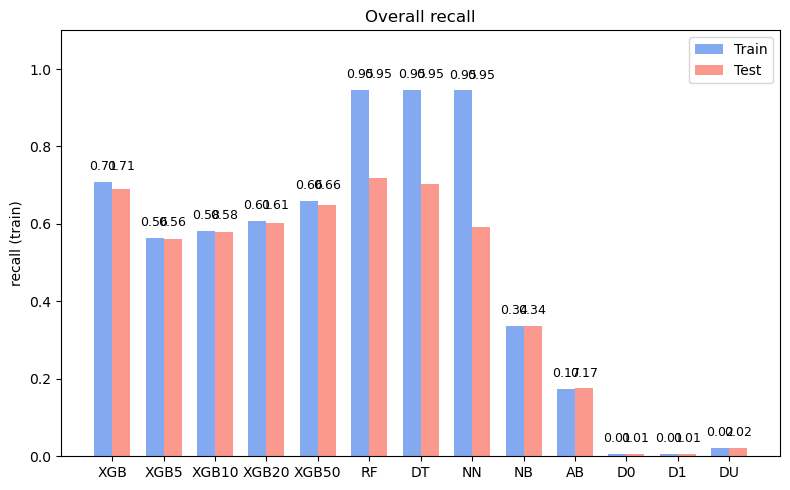

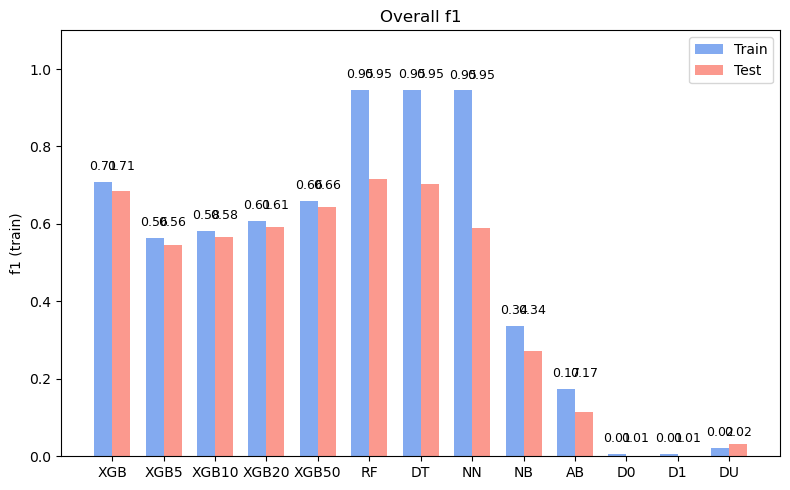

In [18]:
for mn in ml_metrics_names:
    if "train" in mn:
        mn_train = mn
        mn_test = mn.replace("train", "test")

        # Data for the two series
        train_metrics = ml_metrics[mn_train]
        test_metrics  = ml_metrics[mn_test]

        x = np.arange(len(model_names_short))   # positions
        width = 0.35

        plt.figure(figsize=(8, 5))

        # Two bar groups
        plt.bar(x - width/2, train_metrics, width,
                capsize=5,
                label='Train', color='cornflowerblue', alpha=0.8)

        plt.bar(x + width/2, test_metrics, width,
                capsize=5,
                label='Test', color='salmon', alpha=0.8)

        # Labels & layout
        plt.xticks(x, model_names_short)
        plt.ylabel(mn)
        plt.title(f'Overall {mn.replace(" (train)", "")}')

        if "time" not in mn:
            plt.ylim(0, 1.1)

        # Add mean value labels above bars
        for i, val in enumerate(train_metrics):
            plt.text(x[i] - width/2, val + 0.03, f"{val:.2f}",
                    ha='center', fontsize=9)

        for i, val in enumerate(train_metrics):
            plt.text(x[i] + width/2, val + 0.03, f"{val:.2f}",
                    ha='center', fontsize=9)

        plt.legend()
        plt.tight_layout()
        plt.show()